# Lindsey's method for MLE and EB

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"

sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
from npeb import Grenander, local_fdr
import scipy.stats as stats
from scipy.io import loadmat
from scipy.integrate import quad
import matplotlib.pyplot as plt
from scipy.optimize import isotonic_regression, minimize
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
import jax
import jax.numpy as jnp
import optax

from calibration_helpers.mixtures import make_pvals
from calibration_helpers.misc import qvalues

from calibration_helpers.calibrators import (
  LindseyLfdrCalibrator,
  SplineMLELfdrCalibrator
)

(CVXPY) May 20 05:53:17 PM: Encountered unexpected exception importing solver MOSEK:
ImportError("cannot import name '_msk' from partially initialized module 'mosek' (most likely due to a circular import) (/Users/adway/src/research-code/calibration-multiple-testing/.venv/lib/python3.14/site-packages/mosek/__init__.py)")


## Example experiment

In [2]:
labels, pvals = make_pvals(n=50_000, pi0=0.50, alpha=0.5, beta=2.3)
qvals = qvalues(pvals, lam=0.5)

train_idx = np.random.choice(len(pvals), size=int(0.5 * len(pvals)), replace=False)
train_pvals = pvals[train_idx]
train_labels = labels[train_idx]
test_pvals = pvals[~np.isin(pvals, train_pvals)]
test_labels = labels[~np.isin(pvals, train_pvals)]

lam = 1 - len(test_pvals)**(-1/5)
pi_hat_0_gren = np.mean(test_pvals > lam) / (1 - lam)

In [3]:
cal_lindsey = LindseyLfdrCalibrator()
cal_lindsey.fit(train_pvals)
test_lfdr_lindsey = cal_lindsey.predict(test_pvals)

In [4]:
cal_reg = SplineMLELfdrCalibrator()
cal_reg.fit(train_pvals)
test_lfdr_reg = cal_reg.predict(test_pvals)

In [6]:
def summarize_lfdr_bins(
    df,
    lfdr_col,
    p_col="p_value",
    label_col="label",
    pi0_hat=pi_hat_0_gren,
    bins=np.linspace(0, 1, 10),
):
    tmp = df[[p_col, lfdr_col, label_col]].copy()
    tmp["lfdr_bin"] = pd.cut(
        tmp[lfdr_col],
        bins=bins,
        include_lowest=True,
        right=True
    )

    m = len(tmp)

    out = (
        tmp.groupby("lfdr_bin", observed=False)
        .agg(
            p_min=(p_col, "min"),
            p_max=(p_col, "max"),
            p_mean=(p_col, "mean"),
            lfdr_mean=(lfdr_col, "mean"),
            count=(p_col, "size"),
            proportion_true_nulls=(label_col, "mean"),
        )
        .reset_index()
    )

    # assuming label = 1 means alternative, label = 0 means null
    out["proportion_true_nulls"] = 1 - out["proportion_true_nulls"]

    out["p_bin_length"] = out["p_max"] - out["p_min"]

    out["true_nulls_hat"] = pi0_hat * m * out["p_bin_length"]

    out["proportion_true_nulls_hat"] = np.minimum(
        out["true_nulls_hat"] / out["count"],
        1.0
    )

    out["lfdr_bin_start"] = out["lfdr_bin"].apply(lambda x: x.left)
    out["lfdr_bin_end"] = out["lfdr_bin"].apply(lambda x: x.right)
    out["method"] = lfdr_col

    return out

In [7]:
bins = np.linspace(0, 1, 10)

test_df = pd.DataFrame({
    "p_value": test_pvals,
    "lfdr_reg": test_lfdr_reg,
    "lfdr_lindsey": test_lfdr_lindsey,
    "label": test_labels,
})

stats_reg = summarize_lfdr_bins(
    test_df,
    lfdr_col="lfdr_reg",
    bins=bins,
    pi0_hat=pi_hat_0_gren
)

stats_lindsey = summarize_lfdr_bins(
    test_df,
    lfdr_col="lfdr_lindsey",
    bins=bins,
    pi0_hat=pi_hat_0_gren
)

lfdr_bin_stats = pd.concat([stats_reg, stats_lindsey], ignore_index=True)

lfdr_bin_stats = pd.concat([stats_reg, stats_lindsey], ignore_index=True)

print(lfdr_bin_stats)

           lfdr_bin         p_min     p_max    p_mean  lfdr_mean  count  \
0   (-0.001, 0.111]  7.348147e-10  0.012544  0.004359   0.059094   2397   
1    (0.111, 0.222]  1.258683e-02  0.032464  0.021849   0.170735   1552   
2    (0.222, 0.333]  3.247853e-02  0.104246  0.065032   0.258007   3577   
3    (0.333, 0.444]  1.042868e-01  0.195432  0.148041   0.385558   3054   
4    (0.444, 0.556]  1.955555e-01  0.334723  0.261455   0.488240   3573   
5    (0.556, 0.667]  3.347690e-01  0.485386  0.392123   0.611005   1845   
6    (0.667, 0.778]  4.003402e-01  0.627075  0.496872   0.716406   2959   
7    (0.778, 0.889]  5.497028e-01  0.774401  0.656842   0.825014   2219   
8      (0.889, 1.0]  6.639479e-01  0.999976  0.842929   0.963874   3824   
9   (-0.001, 0.111]  7.348147e-10  0.016890  0.005851   0.076210   2801   
10   (0.111, 0.222]  1.691123e-02  0.042117  0.028944   0.163970   1790   
11   (0.222, 0.333]  4.215681e-02  0.117343  0.077046   0.302348   3444   
12   (0.333, 0.444]  1.17

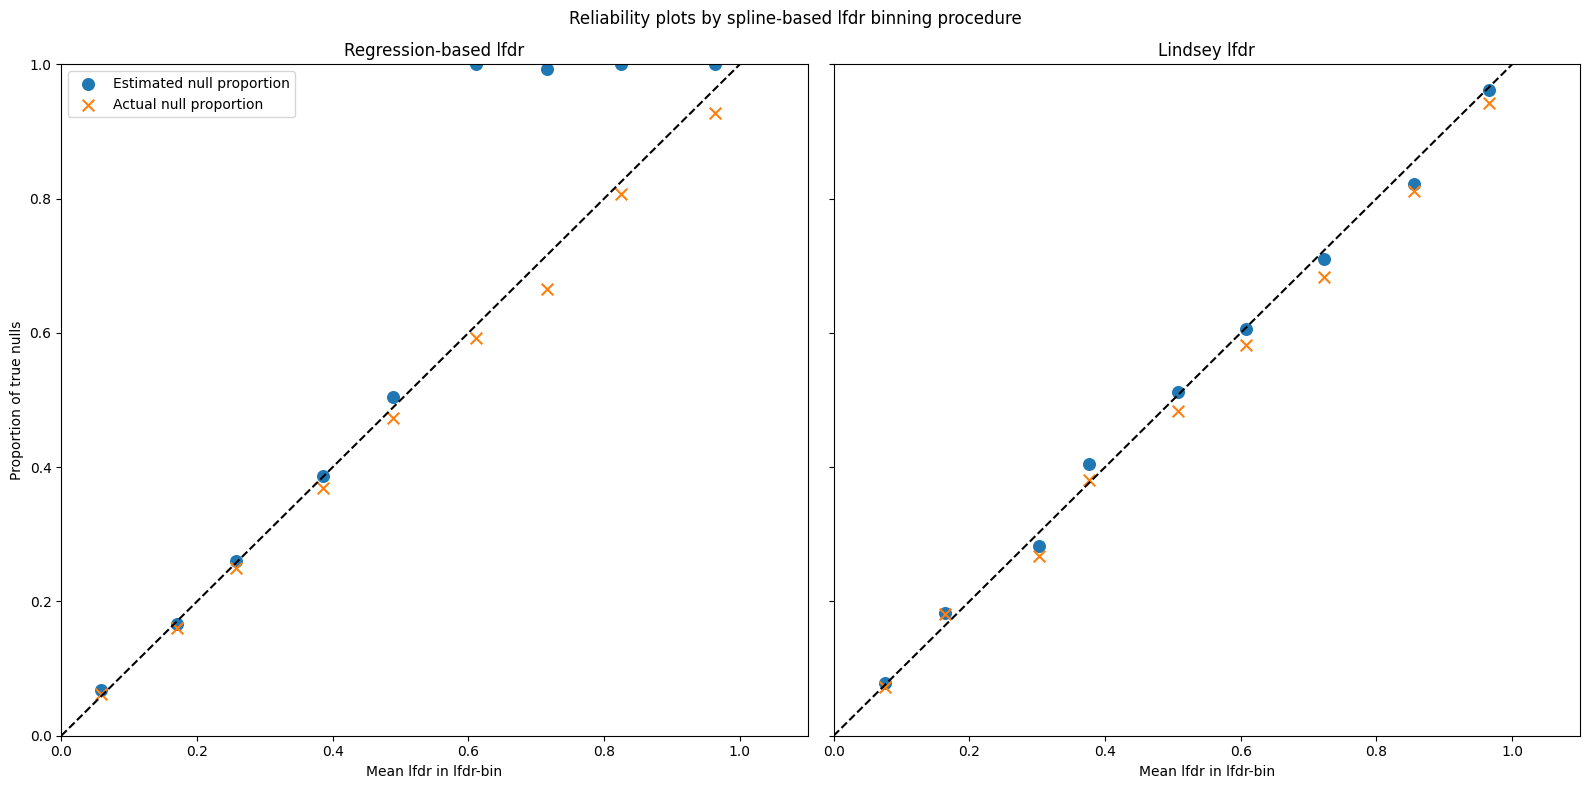

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

plot_configs = [
    ("lfdr_reg", axes[0], "Regression-based lfdr"),
    ("lfdr_lindsey", axes[1], "Lindsey lfdr"),
]

for method, ax, title in plot_configs:

    sub = lfdr_bin_stats[lfdr_bin_stats["method"] == method]

    sub = sub.dropna(
        subset=[
            "lfdr_mean",
            "proportion_true_nulls_hat",
            "proportion_true_nulls"
        ]
    )

    # estimated null proportion
    ax.scatter(
        sub["lfdr_mean"],
        sub["proportion_true_nulls_hat"],
        label="Estimated null proportion",
        s=70,
        marker="o"
    )

    # actual null proportion
    ax.scatter(
        sub["lfdr_mean"],
        sub["proportion_true_nulls"],
        label="Actual null proportion",
        s=70,
        marker="x"
    )

    # ideal calibration
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.5)

    ax.set_title(title)
    ax.set_xlabel("Mean lfdr in lfdr-bin")
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Proportion of true nulls")

axes[0].legend()

plt.suptitle("Reliability plots by spline-based lfdr binning procedure")

plt.tight_layout()

plt.show()